## Cell 1: Environment Setup and Kaggle Authentication

Installs the Kaggle client and configures your API key. This version uses the
**actual uploaded filename** and verifies the key was placed correctly, so it
fails loudly if authentication does not work (rather than silently relying on
a previous session's credentials).

**To get your key:** Kaggle → Settings → API → Create New Token →
kaggle.json downloads. Upload it when prompted.


In [ ]:
!pip install -q --upgrade kaggle

from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Fail clearly if nothing was uploaded.
if not uploaded:
    raise RuntimeError("No Kaggle API file was uploaded.")

# Use whatever the file was actually named (e.g. 'kaggle(2).json').
uploaded_name = next(iter(uploaded))

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as destination:
    destination.write(uploaded[uploaded_name])
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Verify the key is really in place.
if not os.path.exists("/root/.kaggle/kaggle.json"):
    raise RuntimeError("Kaggle API configuration failed.")

print("✅ Kaggle API configured successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 15.2 MB/s eta 0:00:00
Please upload your kaggle.json file:


Saving kaggle(2).json to kaggle(2).json
✅ Kaggle API configured successfully.


## Cell 2:Imports and Reproducibility

This cell imports all libraries used throughout the notebook and fixes the
random seeds. Fixing seeds means your results are (largely) reproducible for my
report and my reported numbers can be regenerated.

In [ ]:
#Standard data / numerical libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras import layers, models

#Evaluation metrics (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

#Image handling
import cv2                              # OpenCV, used for image reading and resizing

#Reproducibility: fix random seeds
SEED = 42                               # any fixed integer works
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Confirm GPU availability
gpus = tf.config.list_physical_devices('GPU')
print("TensorFlow version:", tf.__version__)
print("GPU available:" , "YES ✅" if gpus else "NO ❌  (enable via Runtime > Change runtime type)")

TensorFlow version: 2.20.0
GPU available: NO ❌  (enable via Runtime > Change runtime type)


## Cell 3: To download CBIS-DDSM and MIAS

This cell downloads both datasets straight from Kaggle using the API key
configured in Cell 1.

- **CBIS-DDSM** (main dataset) — curated mammography images with pathology
  labels (benign / malignant). Used for training and internal evaluation.
- **MIAS** (comparison dataset) — a smaller, independent mammography dataset
  used later for cross-dataset (domain-shift) evaluation.

In [ ]:
#Create a folder to hold the datasets
os.makedirs('/content/data', exist_ok=True)

#Download the MAIN dataset: CBIS-DDSM
print("Downloading CBIS-DDSM (this can take several minutes)...")
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset \
        -p /content/data/cbis --unzip -q

#Download the COMPARISON dataset: MIAS
print("Downloading MIAS...")
!kaggle datasets download -d kmader/mias-mammography \
        -p /content/data/mias --unzip -q

print("\n✅ Downloads complete.")

#Peek at what was downloaded
print("\nCBIS-DDSM top-level contents:")
print(os.listdir('/content/data/cbis'))
print("\nMIAS top-level contents:")
print(os.listdir('/content/data/mias'))

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
Dataset URL: https://www.kaggle.com/datasets/kmader/mias-mammography
License(s): other

✅ Downloads complete.

CBIS-DDSM top-level contents:
['jpeg', 'csv']

MIAS top-level contents:
['all-mias', 'all-mias.tar.gz', 'Info.txt', 'all_mias_scans.h5']


## Cell 4:Inspect CBIS-DDSM Metadata

CBIS-DDSM does not store labels inside the images. Instead, CSV files
describe each case, including its pathology (BENIGN / BENIGN_WITHOUT_CALLBACK
/ MALIGNANT) and the image file paths.

This cell locates and loads those CSV files and prints their columns so we
can see exactly what we are working with. Datasets on Kaggle sometimes change
folder structure, so we search for the CSVs rather than hard-coding paths.

In [ ]:
#Find every CSV file inside the CBIS folder
csv_files = []
for root, dirs, filenames in os.walk('/content/data/cbis'):
    for f in filenames:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print("CSV files found in CBIS-DDSM:")
for c in csv_files:
    print("  ", c)

#Load one CSV to inspect its structure
# The 'dicom_info.csv' file maps image paths; the 'case description'
# files hold the pathology labels. We inspect them below.
for c in csv_files:
    print("\n" + "="*70)
    print("FILE:", os.path.basename(c))
    df_tmp = pd.read_csv(c)
    print("Shape:", df_tmp.shape)
    print("Columns:", list(df_tmp.columns))
    print(df_tmp.head(2))

CSV files found in CBIS-DDSM:
   /content/data/cbis/csv/mass_case_description_train_set.csv
   /content/data/cbis/csv/mass_case_description_test_set.csv
   /content/data/cbis/csv/dicom_info.csv
   /content/data/cbis/csv/calc_case_description_test_set.csv
   /content/data/cbis/csv/meta.csv
   /content/data/cbis/csv/calc_case_description_train_set.csv

FILE: mass_case_description_train_set.csv
Shape: (1318, 14)
Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001               3                 LEFT         CC               1   
1    P_00001               3                 LEFT        MLO               1   

  abnormality type                          mass shape mass margins  \
0             mass  

## Cell 5 — Build the Labelled Image Table (corrected)

CBIS-DDSM stores labels and images separately, so this cell joins them and
assigns one reliable label per image.

The join uses a readable key (patient + breast side + view). The important
correction here: a single mammogram can contain **multiple findings**, which
may disagree (one benign, one malignant). Rather than keeping whichever label
appears first, we assign **malignant if ANY finding in that image is
malignant** — the clinically correct rule. We also report how many images had
conflicting finding labels, and remove duplicate image records.

**Steps:**
1. Combine the four case-description CSVs.
2. Clean and map pathology → binary (Benign 0 / Malignant 1), reporting any
   unexpected pathology values.
3. Collapse findings to one label per image (malignant takes precedence).
4. Keep only full mammogram JPEGs, deduplicated, that exist on disk.
5. Join labels to images on the key.

In [ ]:
# ── Paths and helpers ───────────────────────────────────────────
CSV_DIR   = '/content/data/cbis/csv'
JPEG_BASE = '/content/data/cbis'

def dicom_to_abs(image_path):
    rel = str(image_path).replace('CBIS-DDSM/', '')
    return os.path.join(JPEG_BASE, rel)

# ── Step 1: combine the four case-description CSVs ──────────────
case_files = [
    'mass_case_description_train_set.csv',
    'mass_case_description_test_set.csv',
    'calc_case_description_train_set.csv',
    'calc_case_description_test_set.csv',
]
cases = pd.concat(
    [pd.read_csv(os.path.join(CSV_DIR, f)) for f in case_files],
    ignore_index=True
)
print("Total case (finding) rows:", len(cases))

# ── Step 2: clean pathology and map to binary ──────────────────
pathology_map = {
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
    "MALIGNANT": 1,
}
cases["pathology_clean"] = cases["pathology"].astype(str).str.upper().str.strip()

# Report any pathology values we didn't expect (should be empty).
unknown = sorted(set(cases["pathology_clean"]) - set(pathology_map))
print("Unknown pathology values:", unknown)

cases = cases[cases["pathology_clean"].isin(pathology_map)].copy()
cases["label"] = cases["pathology_clean"].map(pathology_map)

# ── Build the join key: patient + side + view ──────────────────
cases["key"] = (
    cases["patient_id"].astype(str) + "_" +
    cases["left or right breast"].astype(str) + "_" +
    cases["image view"].astype(str)
).str.upper().str.replace(" ", "", regex=False)

# ── Step 3: one label per image (malignant if ANY finding is) ──
image_labels = (
    cases.groupby("key", as_index=False)
    .agg(
        label=("label", "max"),              # malignant (1) wins
        finding_count=("label", "size"),
        different_labels=("label", "nunique")
    )
)
n_conflict = (image_labels["different_labels"] > 1).sum()
print("Images with conflicting finding labels (resolved as malignant):", n_conflict)
print("Total labelled images (unique keys):", len(image_labels))

# ── Step 4: full-mammogram JPEGs, deduplicated ─────────────────
dicom = pd.read_csv(os.path.join(CSV_DIR, 'dicom_info.csv'))
full = dicom[dicom['SeriesDescription'] == 'full mammogram images'].copy()
full['abs_path'] = full['image_path'].apply(dicom_to_abs)

def dicom_key(pid):
    parts = str(pid).upper().split('_')
    for i, part in enumerate(parts):
        if part == 'P' and i + 3 < len(parts) + 1:
            return '_'.join(parts[i:i+4])
    return None
full['key'] = full['PatientID'].apply(dicom_key)

print("Duplicate full-image keys before dedup:", full['key'].duplicated().sum())
full = full.drop_duplicates(subset='key').copy()

# ── Step 5: join image labels to physical files ────────────────
merged = image_labels[['key', 'label']].merge(
    full[['key', 'abs_path']], on='key', how='inner'
)
merged = merged[merged['abs_path'].apply(os.path.exists)].reset_index(drop=True)
merged = merged.drop_duplicates(subset='abs_path').reset_index(drop=True)

print("\nLabelled images matched to files:", len(merged))
print("Class balance (0=Benign, 1=Malignant):")
print(merged['label'].value_counts())
merged.head()

Total case (finding) rows: 3568
Unknown pathology values: []
Images with conflicting finding labels (resolved as malignant): 33
Total labelled images (unique keys): 3032
Duplicate full-image keys before dedup: 55

Labelled images matched to files: 2802
Class balance (0=Benign, 1=Malignant):
label
0    1544
1    1258
Name: count, dtype: int64


,key,label,abs_path
0,P_00001_LEFT_CC,1,/content/data/cbis/jpeg/1.3.6.1.4.1.9590.100.1...
1,P_00001_LEFT_MLO,1,/content/data/cbis/jpeg/1.3.6.1.4.1.9590.100.1...
2,P_00004_LEFT_CC,0,/content/data/cbis/jpeg/1.3.6.1.4.1.9590.100.1...
3,P_00004_LEFT_MLO,0,/content/data/cbis/jpeg/1.3.6.1.4.1.9590.100.1...
4,P_00004_RIGHT_MLO,0,/content/data/cbis/jpeg/1.3.6.1.4.1.9590.100.1...


## Cell 6 — Use Full Dataset and Preview

Rather than undersampling to a fixed number per class (which discards usable
data), we keep **all matched images**. The mild class imbalance (more benign
than malignant) is handled later using class weights during training, which
is more defensible than discarding over a thousand images.

Final dataset size: 2802
Class distribution:
label
0    1544
1    1258
Name: count, dtype: int64


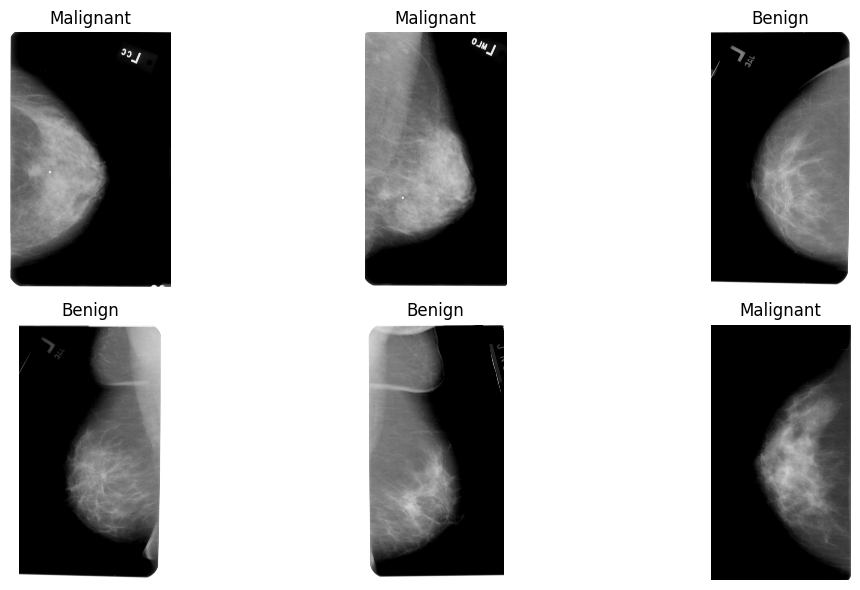

In [ ]:
# ── Use ALL matched images (no undersampling) ──────────────────
# Instead of discarding data, we keep all 2,802 images and handle
# the mild class imbalance later with class weights during training.
balanced = merged.copy().reset_index(drop=True)

print("Final dataset size:", len(balanced))
print("Class distribution:")
print(balanced['label'].value_counts())

# ── Preview 6 images ───────────────────────────────────────────
plt.figure(figsize=(12, 6))
for i in range(6):
    img = cv2.imread(balanced['abs_path'][i], cv2.IMREAD_GRAYSCALE)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Malignant" if balanced['label'][i] == 1 else "Benign")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Cell 7:Data Cleaning, Patient-Level Split, and Datasets

This improved version adds two data-quality safeguards before building the
datasets:

1. **Corrupt-image check** — every image is test-decoded; any unreadable
   files are dropped so training cannot crash on a bad file.
2. **Patient-level split** — the train/validation/test split is done by
   *patient*, not by image. Because one patient can contribute several images
   (CC/MLO, left/right), an image-level split could place a patient's images
   in both training and test sets. That is **data leakage** and inflates test
   scores. Splitting by patient prevents it and gives a fair evaluation.

After cleaning, images are resized to 224×224, normalised to 0–1, and
training-set augmentation is applied.

In [ ]:
# 0. Recover patient id from each image's key/path
# The 'key' column (e.g. 'P_00001_LEFT_CC') starts with the patient id.
def patient_of(key):
    # 'P_00001_LEFT_CC' -> 'P_00001'
    parts = str(key).split('_')
    return parts[0] + '_' + parts[1] if len(parts) >= 2 else str(key)

# balanced still has 'abs_path' and 'label'; re-attach the key/patient.
key_lookup = dict(zip(merged['abs_path'], merged['key'])) \
             if 'key' in merged.columns else {}

def get_patient(row):
    k = key_lookup.get(row['abs_path'])
    if k is not None:
        return patient_of(k)
    return os.path.basename(os.path.dirname(row['abs_path']))

balanced['patient'] = balanced.apply(get_patient, axis=1)

# 1. Corrupt-image check: keep only readable JPEGs
def is_readable(path):
    try:
        img = cv2.imread(path)
        return img is not None and img.size > 0
    except Exception:
        return False

before = len(balanced)
balanced = balanced[balanced['abs_path'].apply(is_readable)].reset_index(drop=True)
print(f"Corrupt-image check: kept {len(balanced)} of {before} images.")

# 2. Patient-level split (no patient appears in two splits)
from sklearn.model_selection import GroupShuffleSplit

def group_split(df, test_size, seed):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(df, groups=df['patient']))
    return df.iloc[idx_a].reset_index(drop=True), df.iloc[idx_b].reset_index(drop=True)

train_df, temp_df = group_split(balanced, test_size=0.30, seed=SEED)
val_df,   test_df = group_split(temp_df,  test_size=0.50, seed=SEED)

# ── Sanity check: verify ALL THREE split pairs share no patients ──
train_test_overlap = set(train_df['patient']) & set(test_df['patient'])
train_val_overlap  = set(train_df['patient']) & set(val_df['patient'])
val_test_overlap   = set(val_df['patient'])   & set(test_df['patient'])

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("Train–Test patient overlap (should be empty set):", train_test_overlap)
print("Train–Val  patient overlap (should be empty set):", train_val_overlap)
print("Val–Test   patient overlap (should be empty set):", val_test_overlap)
print("Train class balance:\n", train_df['label'].value_counts())
print("Val class balance:\n",   val_df['label'].value_counts())
print("Test class balance:\n",  test_df['label'].value_counts())

# 3. Build datasets
IMG_SIZE = 224
BATCH    = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['abs_path'].values, df['label'].values.astype('float32'))
    )
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(500, seed=SEED)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

# 4. Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# 5. Class weights to handle mild imbalance (computed on TRAIN set only)
# With the full dataset there are more benign than malignant images.
# Class weights let the model pay proportionally more attention to the
# minority (malignant) class instead of discarding data by undersampling.
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values
)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)

print("✅ Cleaned datasets ready (patient-level split, full dataset, class weights).")

Corrupt-image check: kept 2802 of 2802 images.
Train: 1966  Val: 416  Test: 420
Train–Test patient overlap (should be empty set): set()
Train–Val  patient overlap (should be empty set): set()
Val–Test   patient overlap (should be empty set): set()
Train class balance:
 label
0    1104
1     862
Name: count, dtype: int64
Val class balance:
 label
0    232
1    184
Name: count, dtype: int64
Test class balance:
 label
1    212
0    208
Name: count, dtype: int64
Class weights: {0: np.float64(0.8903985507246377), 1: np.float64(1.140371229698376)}
✅ Cleaned datasets ready (patient-level split, full dataset, class weights).


## Cell 8 : Baseline CNN Model

This builds the baseline convolutional neural network — the starting point
that later transfer-learning models will be compared against.

It is intentionally simple (three convolutional blocks) so it can be
described clearly and serves as a fair baseline. It improves on the prototype
by including the augmentation layer and dropout to reduce overfitting.

Architecture: 3 × [Conv → ReLU → MaxPool] → Flatten → Dense → Dropout →
Sigmoid output (binary classification).

In [ ]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,                                   # augment on the fly

        layers.Conv2D(32, 3, activation='relu'),             # block 1
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),             # block 2
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),            # block 3
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),                                 # regularisation
        layers.Dense(1, activation='sigmoid')                # binary output
    ], name="baseline_cnn")

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

baseline = build_baseline_cnn()
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 8b — Shared Evaluation Helper (with extra clinical metrics)

A single reusable evaluation function used for every model, so results are
computed identically and are directly comparable. In addition to accuracy and
ROC-AUC, it reports metrics that matter more for cancer detection:

- **Sensitivity (recall for malignant)** — how many cancers are caught
- **Specificity** — how many benign cases are correctly cleared
- **PR-AUC** — precision-recall AUC, more informative than ROC-AUC when the
  positive (malignant) class is the clinical priority

In [ ]:
from sklearn.metrics import average_precision_score

# ── Plot training curves ───────────────────────────────────────
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history['accuracy'], label='train')
    ax[0].plot(h.history['val_accuracy'], label='val')
    ax[0].set_title(f'{title} — Accuracy'); ax[0].legend()
    ax[1].plot(h.history['loss'], label='train')
    ax[1].plot(h.history['val_loss'], label='val')
    ax[1].set_title(f'{title} — Loss'); ax[1].legend()
    plt.show()

# ── Shared evaluation with extra clinical metrics ──────────────
def evaluate_model(model, name, is_array=False, X=None, y=None):
    if is_array:
        y_true = y
        y_prob = model.predict(X, batch_size=16).ravel()
    else:
        y_true = np.concatenate([yy.numpy() for _, yy in test_ds])
        y_prob = model.predict(test_ds).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    acc = (y_pred == y_true).mean()
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\n── {name} ──")
    print(f"Accuracy    : {acc:.4f}")
    print(f"ROC-AUC     : {auc:.4f}")
    print(f"PR-AUC      : {pr_auc:.4f}")
    print(f"Sensitivity : {sensitivity:.4f}  (malignant recall)")
    print(f"Specificity : {specificity:.4f}  (benign recall)")
    print(classification_report(y_true, y_pred,
                                target_names=['Benign','Malignant'], zero_division=0))
    print("Confusion matrix [[TN FP][FN TP]]:\n", confusion_matrix(y_true, y_pred))

    return {'name': name, 'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc,
            'sensitivity': sensitivity, 'specificity': specificity,
            'y_true': y_true, 'y_prob': y_prob, 'y_pred': y_pred}

# ── Fresh EarlyStopping for EACH model ─────────────────────────
def make_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max',
        patience=4, restore_best_weights=True
    )

print("✅ Helpers ready: plot_history, evaluate_model, make_early_stopping.")

✅ Helpers ready: plot_history, evaluate_model, make_early_stopping.


## Cell 9 — Train and Evaluate the Baseline CNN

Trains the baseline CNN using a **fresh EarlyStopping callback** (so no state
carries over between models) and evaluates it with the shared helper, which
now also reports sensitivity, specificity and PR-AUC.

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.5219 - auc: 0.5295 - loss: 0.6965 - val_accuracy: 0.6226 - val_auc: 0.5848 - val_loss: 0.6916
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.5443 - auc: 0.5561 - loss: 0.6917 - val_accuracy: 0.6250 - val_auc: 0.6178 - val_loss: 0.6809
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.5834 - auc: 0.5872 - loss: 0.6861 - val_accuracy: 0.4688 - val_auc: 0.6516 - val_loss: 0.7366
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.5605 - auc: 0.5837 - loss: 0.6889 - val_accuracy: 0.5745 - val_auc: 0.6425 - val_loss: 0.6745
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.5931 - auc: 0.6023 - loss: 0.6804 - val_accuracy: 0.6034 - val_auc: 0.6352 - val_loss: 0.6900
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.5743 - auc: 0.6046 - loss: 0.6805 - val_accuracy: 0.4880 - val_auc: 0.6287 - val_loss: 0.7328
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━

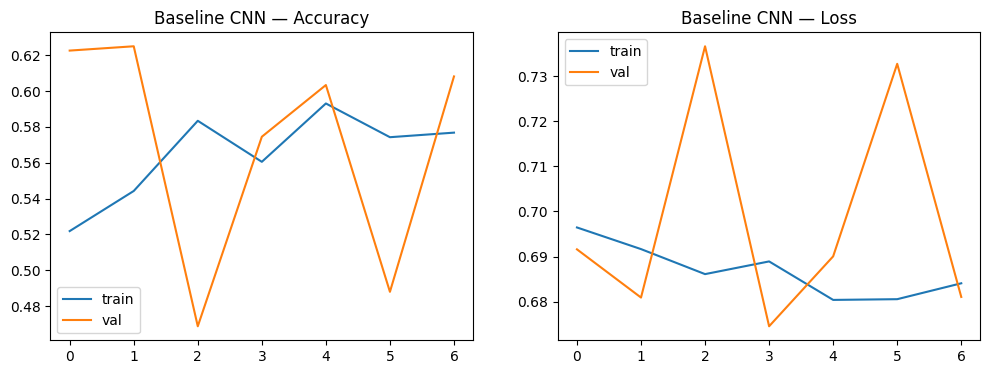

27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 826ms/step

── Baseline CNN (CBIS-DDSM) ──
Accuracy    : 0.5143
ROC-AUC     : 0.5809
PR-AUC      : 0.5974
Sensitivity : 0.9623  (malignant recall)
Specificity : 0.0577  (benign recall)
              precision    recall  f1-score   support

      Benign       0.60      0.06      0.11       208
   Malignant       0.51      0.96      0.67       212

    accuracy                           0.51       420
   macro avg       0.55      0.51      0.39       420
weighted avg       0.55      0.51      0.39       420

Confusion matrix [[TN FP][FN TP]]:
 [[ 12 196]
 [  8 204]]


In [ ]:
history = baseline.fit(
    train_ds, validation_data=val_ds,
    epochs=15, callbacks=[make_early_stopping()],
    class_weight=class_weights                       # handle mild imbalance
)

plot_history(history, "Baseline CNN")
baseline_res = evaluate_model(baseline, "Baseline CNN (CBIS-DDSM)")

## Cell 10 : Transfer Learning (ResNet50 and EfficientNetB0)

The baseline CNN learned little because training a deep network from scratch
needs far more data than we have. **Transfer learning** reuses a network
already trained on millions of natural images (ImageNet) and adapts it to
mammograms.

**Method (feature extraction):**
- Load a pretrained base (ResNet50 / EfficientNetB0) *without* its top layer.
- **Freeze** the base so its learned features are kept.
- Add a small trainable classifier head (pooling → dropout → sigmoid).
- Train only the new head on our mammograms.

We build a reusable function and train both architectures so they can be
compared against the baseline and each other. Each model uses the
preprocessing function its architecture expects.

In [ ]:
for name in ['IMG_SIZE', 'BATCH', 'train_ds', 'val_ds', 'test_ds',
             'data_augmentation', 'make_early_stopping', 'evaluate_model',
             'plot_history', 'merged', 'balanced', 'train_df']:
    print(f"{name:22}", "✓" if name in dir() else "✗ MISSING")

IMG_SIZE               ✓
BATCH                  ✓
train_ds               ✓
val_ds                 ✓
test_ds                ✓
data_augmentation      ✓
make_early_stopping    ✓
evaluate_model         ✓
plot_history           ✓
merged                 ✓
balanced               ✓
train_df               ✓


ResNet50 — Stage 1: feature extraction...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 375s 3s/step - accuracy: 0.5102 - auc: 0.5182 - loss: 0.8254 - val_accuracy: 0.5120 - val_auc: 0.5488 - val_loss: 0.7488
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 396s 3s/step - accuracy: 0.5107 - auc: 0.5220 - loss: 0.8086 - val_accuracy: 0.5216 - val_auc: 0.5718 - val_loss: 0.7167
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 387s 3s/step - accuracy: 0.5468 - auc: 0.5694 - loss: 0.7636 - val_accuracy: 0.5457 - val_auc: 0.5899 - val_loss: 0.6890
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 363s 3s/step - accuracy: 0.5453 - auc: 0.5712 - loss: 0.7601 - val_accuracy: 0.5409 - val_auc: 0.6076 - val_loss: 0.6998
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 402s 3s/step - accuracy: 0.5493 - auc: 0.5705 - loss: 0.7583 - val_accuracy: 0.5433 - val_auc: 0.6172 - val_loss: 0.6984
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 389s 3s/step - accuracy: 0.5636 - auc: 0.5868 - loss: 0.7405 -

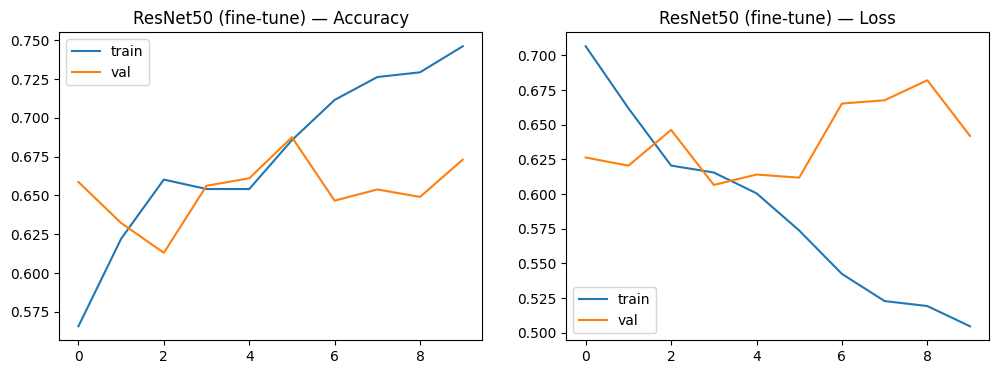

27/27 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step

── ResNet50 (CBIS-DDSM, fine-tuned) ──
Accuracy    : 0.6238
ROC-AUC     : 0.6861
PR-AUC      : 0.6552
Sensitivity : 0.9198  (malignant recall)
Specificity : 0.3221  (benign recall)
              precision    recall  f1-score   support

      Benign       0.80      0.32      0.46       208
   Malignant       0.58      0.92      0.71       212

    accuracy                           0.62       420
   macro avg       0.69      0.62      0.59       420
weighted avg       0.69      0.62      0.59       420

Confusion matrix [[TN FP][FN TP]]:
 [[ 67 141]
 [ 17 195]]

EfficientNetB0 — Stage 1: feature extraction...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.4517 - auc: 0.4515 - loss: 0.7454 - val_accuracy: 0.4904 - val_auc: 0.4763 - val_loss: 0.7083
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5061 - auc: 0.4987 - loss: 0.7184 - val_accuracy: 0.5192 - val_au

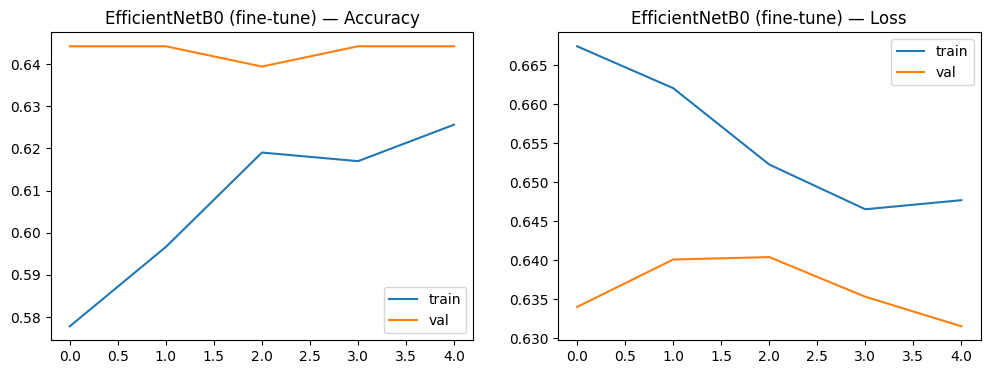

27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step

── EfficientNetB0 (CBIS-DDSM, fine-tuned) ──
Accuracy    : 0.5881
ROC-AUC     : 0.6322
PR-AUC      : 0.6176
Sensitivity : 0.6509  (malignant recall)
Specificity : 0.5240  (benign recall)
              precision    recall  f1-score   support

      Benign       0.60      0.52      0.56       208
   Malignant       0.58      0.65      0.61       212

    accuracy                           0.59       420
   macro avg       0.59      0.59      0.59       420
weighted avg       0.59      0.59      0.59       420

Confusion matrix [[TN FP][FN TP]]:
 [[109  99]
 [ 74 138]]


In [ ]:
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pre

def build_transfer_model(base_type):
    if base_type == 'resnet50':
        base = ResNet50(include_top=False, weights='imagenet',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = resnet_pre
    else:
        base = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = effnet_pre

    base.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(lambda img: img * 255.0)(x)
    x = preprocess(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs, name=f"{base_type}_transfer")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model, base

# ResNet50
print("ResNet50 — Stage 1: feature extraction...")
resnet, resnet_base = build_transfer_model('resnet50')
resnet.fit(train_ds, validation_data=val_ds, epochs=15,
           callbacks=[make_early_stopping()], class_weight=class_weights)

print("\nResNet50 — Stage 2: fine-tuning...")
resnet_base.trainable = True
for layer in resnet_base.layers:
    if not layer.name.startswith('conv5'):
        layer.trainable = False
resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy',
               metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
resnet_ft_hist = resnet.fit(train_ds, validation_data=val_ds, epochs=10,
                            callbacks=[make_early_stopping()], class_weight=class_weights)
plot_history(resnet_ft_hist, "ResNet50 (fine-tune)")
resnet_res = evaluate_model(resnet, "ResNet50 (CBIS-DDSM, fine-tuned)")

# EfficientNetB0
print("\nEfficientNetB0 — Stage 1: feature extraction...")
effnet, effnet_base = build_transfer_model('efficientnet')
effnet.fit(train_ds, validation_data=val_ds, epochs=15,
           callbacks=[make_early_stopping()], class_weight=class_weights)

print("\nEfficientNetB0 — Stage 2: fine-tuning...")
effnet_base.trainable = True
# Fine-tune only the last ~30 layers of EfficientNet.
for layer in effnet_base.layers[:-30]:
    layer.trainable = False
effnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy',
               metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
effnet_ft_hist = effnet.fit(train_ds, validation_data=val_ds, epochs=10,
                            callbacks=[make_early_stopping()], class_weight=class_weights)
plot_history(effnet_ft_hist, "EfficientNetB0 (fine-tune)")
effnet_res = evaluate_model(effnet, "EfficientNetB0 (CBIS-DDSM, fine-tuned)")

In [ ]:
from google.colab import drive
import pickle

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/fyp_models'
os.makedirs(SAVE_DIR, exist_ok=True)

resnet.save(f'{SAVE_DIR}/resnet_finetuned.keras')
effnet.save(f'{SAVE_DIR}/effnet.keras')
baseline.save(f'{SAVE_DIR}/baseline.keras')

def slim(res):
    return {k: v for k, v in res.items()
            if k in ('name','accuracy','auc','pr_auc','sensitivity',
                     'specificity','y_true','y_prob','y_pred')}
with open(f'{SAVE_DIR}/results.pkl', 'wb') as f:
    pickle.dump({'baseline': slim(baseline_res),
                 'resnet': slim(resnet_res),
                 'effnet': slim(effnet_res)}, f)
print("✅ Saved to Drive.")

Mounted at /content/drive
✅ Saved to Drive.


## Cell 11 — Grad-CAM Explainability (class-specific)

Grad-CAM highlights the regions that most influenced a prediction. This
corrected version explains the **predicted class**: for a malignant
prediction it shows evidence increasing malignancy; for a benign prediction
it shows evidence supporting benign. (The earlier version always explained
the malignant output, which is wrong for benign predictions.)

We show correct and incorrect cases and note honestly whether attention falls
on breast tissue or on artefacts such as corner markers.

── CORRECT predictions ──


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_17']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


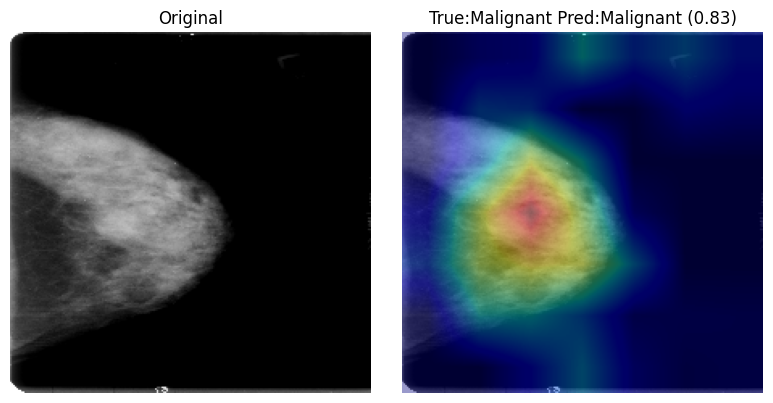

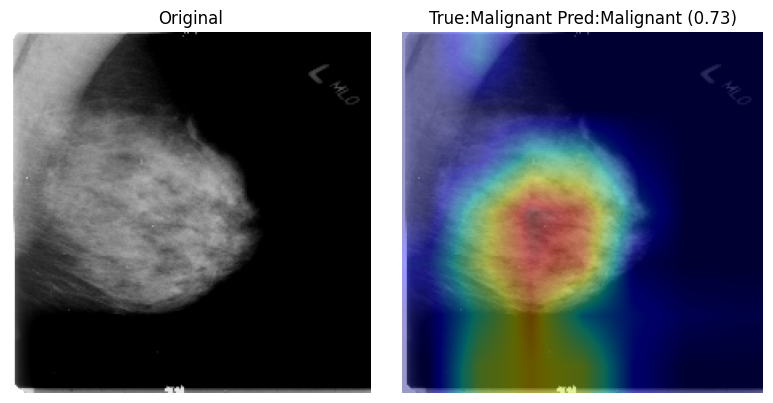

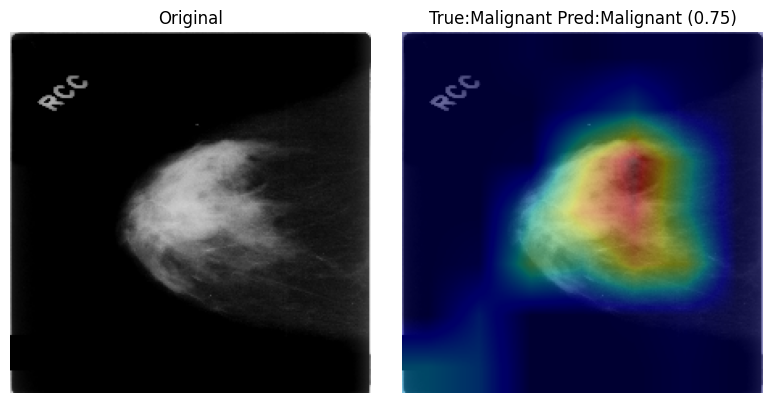

── INCORRECT predictions ──


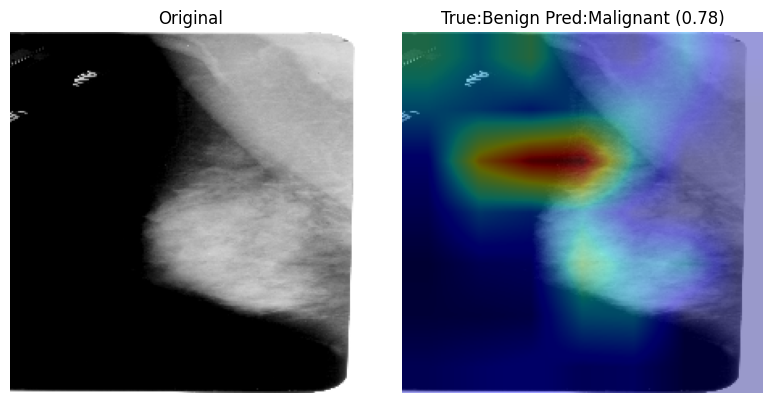

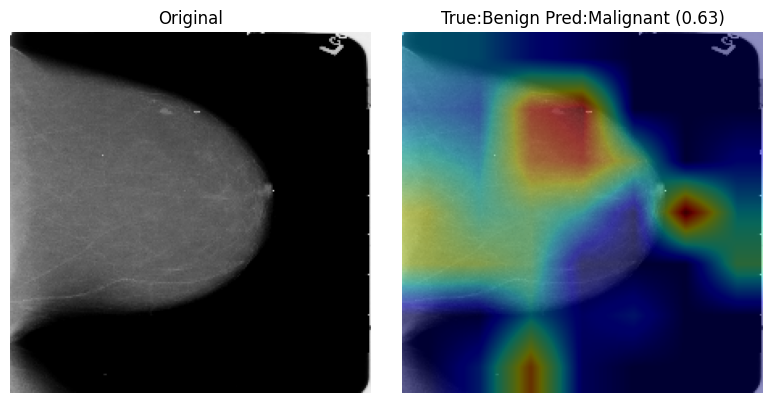

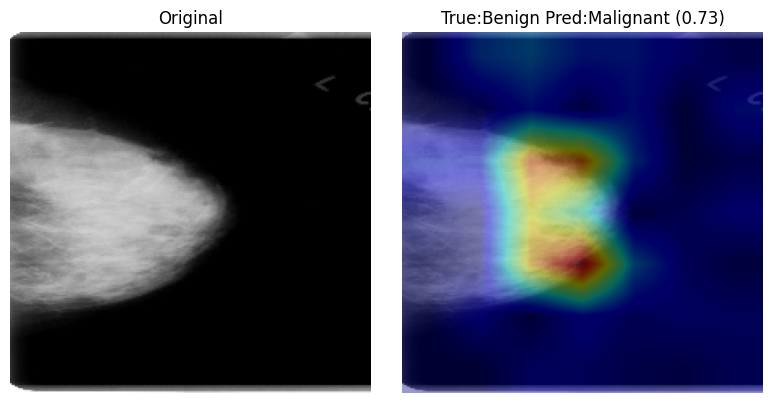

In [ ]:
import matplotlib.cm as cm_map
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre

resnet_base_layer = resnet.get_layer('resnet50')
last_conv_layer_name = 'conv5_block3_out'

base_grad_model = tf.keras.models.Model(
    resnet_base_layer.inputs,
    [resnet_base_layer.get_layer(last_conv_layer_name).output, resnet_base_layer.output]
)

def classifier_head(features):
    x = layers.GlobalAveragePooling2D()(features)
    dense = resnet.get_layer(index=-1)     # trained sigmoid Dense
    return dense(x)

def prep_for_resnet(path):
    raw = cv2.imread(path)
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
    arr = resnet_pre(resized.astype('float32').copy())
    return resized, arr[np.newaxis, ...]

def make_gradcam_heatmap(img_array, target_class):
    with tf.GradientTape() as tape:
        conv_out, _ = base_grad_model(img_array)
        tape.watch(conv_out)
        preds = classifier_head(conv_out)
        # explain the PREDICTED class
        class_score = preds[:, 0] if target_class == 1 else -preds[:, 0]
    grads = tape.gradient(class_score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = tf.squeeze(conv_out @ pooled[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(path, true_label, pred_label, prob):
    resized, arr = prep_for_resnet(path)
    heatmap = make_gradcam_heatmap(arr, target_class=pred_label)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_color = np.uint8(255 * cm_map.jet(heatmap)[..., :3])
    overlay = np.uint8(0.6 * resized + 0.4 * heatmap_color)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(resized); ax[0].set_title("Original"); ax[0].axis('off')
    ax[1].imshow(overlay)
    ax[1].set_title(f"True:{lab[true_label]} Pred:{lab[pred_label]} ({prob:.2f})")
    ax[1].axis('off')
    plt.tight_layout(); plt.show()

lab = {0: 'Benign', 1: 'Malignant'}
test_paths = test_df['abs_path'].values
yt, yp, ypr = resnet_res['y_true'], resnet_res['y_pred'], resnet_res['y_prob']

correct_idx   = np.where(yt == yp)[0][:3]
incorrect_idx = np.where(yt != yp)[0][:3]

print("── CORRECT predictions ──")
for i in correct_idx:
    show_gradcam(test_paths[i], int(yt[i]), int(yp[i]), ypr[i])
print("── INCORRECT predictions ──")
for i in incorrect_idx:
    show_gradcam(test_paths[i], int(yt[i]), int(yp[i]), ypr[i])



## Cell 12: Cross-Dataset Evaluation on MIAS

This is the core contribution of the project. The ResNet50 model was trained
only on CBIS-DDSM. Here we test it — with **no retraining** — on the
independent MIAS dataset. Strong same-dataset performance does not guarantee
the model generalises to images from a different source (different scanners,
resolution, format, population). A large drop here would demonstrate
**domain shift**.

**Steps:**
1. Locate the MIAS images and their labels (MIAS uses a text file where each
   image is marked Normal / Benign / Malignant).
2. Convert to the same binary scheme (Benign vs Malignant); Normal images are
   excluded so the task matches CBIS-DDSM.
3. Preprocess identically (224×224, ResNet preprocessing).
4. Evaluate the already-trained ResNet50 and compare against its CBIS-DDSM
   test performance.

In [ ]:
#Inspect the MIAS folder structure first
print("MIAS folder contents:")
for root, dirs, files in os.walk('/content/data/mias'):
    print(root, "->", files[:6], "..." if len(files) > 6 else "")
    break

# Look for the info/label file (MIAS ships an 'Info.txt' with labels).
for root, dirs, files in os.walk('/content/data/mias'):
    for f in files:
        if 'info' in f.lower() and f.lower().endswith('.txt'):
            print("\nFound label file:", os.path.join(root, f))

MIAS folder contents:
/content/data/mias -> ['all-mias.tar.gz', 'Info.txt', 'all_mias_scans.h5'] 

Found label file: /content/data/mias/Info.txt

Found label file: /content/data/mias/all-mias/Info.txt


## Cell 12b:Inspect MIAS Labels and Image File

Before loading MIAS we inspect two things:
1. The Info.txt label file format — MIAS lists each image with its tissue
   type, abnormality class, and severity (B = benign, M = malignant).
2. The all_mias_scans.h5 file — the Kaggle version bundles all 322 images
   into this single HDF5 file, which is the easiest way to load them.

This lets us write correct, robust loading + cleaning code that matches the
actual data.

In [ ]:
#1. Look at the raw Info.txt label file
info_path = '/content/data/mias/Info.txt'
print("── First 15 lines of Info.txt ──")
with open(info_path, 'r') as f:
    lines = f.readlines()
for line in lines[:15]:
    print(repr(line.strip()))

print(f"\nTotal lines in Info.txt: {len(lines)}")

#2.Inspect the HDF5 image file structure
import h5py
h5_path = '/content/data/mias/all_mias_scans.h5'
print("\n── HDF5 file structure ──")
with h5py.File(h5_path, 'r') as hf:
    for key in hf.keys():
        item = hf[key]
        print(f"Key: '{key}'  shape: {item.shape}  dtype: {item.dtype}")

── First 15 lines of Info.txt ──
'REFNUM BG CLASS SEVERITY X Y RADIUS'
'mdb001 G CIRC B 535 425 197'
'mdb002 G CIRC B 522 280 69'
'mdb003 D NORM'
'mdb004 D NORM'
'mdb005 F CIRC B 477 133 30'
'mdb005 F CIRC B 500 168 26'
'mdb006 F NORM'
'mdb007 G NORM'
'mdb008 G NORM'
'mdb009 F NORM'
'mdb010 F CIRC B 525 425 33'
'mdb011 F NORM'
'mdb012 F CIRC B 471 458 40'
'mdb013 G MISC B 667 365 31'

Total lines in Info.txt: 331

── HDF5 file structure ──
Key: 'BG'  shape: (330,)  dtype: |S1
Key: 'CLASS'  shape: (330,)  dtype: |S4
Key: 'RADIUS'  shape: (330,)  dtype: float64
Key: 'REFNUM'  shape: (330,)  dtype: |S6
Key: 'SEVERITY'  shape: (330,)  dtype: |S32
Key: 'X'  shape: (330,)  dtype: float64
Key: 'Y'  shape: (330,)  dtype: float64
Key: 'path'  shape: (330,)  dtype: |S10
Key: 'scan'  shape: (330, 1024, 1024)  dtype: uint8


## Cell 12c — MIAS Cross-Dataset Evaluation (corrected preprocessing)

The core cross-dataset test. Two corrections from the earlier version:

1. **Preprocessing fixed** — MIAS images are supplied in the same 0–1 range
   used for CBIS-DDSM training. The ResNet model applies its own preprocessing
   internally, so we must NOT call `resnet_pre` here (doing so preprocessed
   the images twice and invalidated the earlier result).
2. **Deduplication by REFNUM** — MIAS lists a mammogram once per finding, so
   images with multiple findings appeared multiple times. We keep one record
   per mammogram (malignant takes precedence).

The trained ResNet50 is evaluated on MIAS with no retraining.

In [ ]:
import h5py
h5_path = '/content/data/mias/all_mias_scans.h5'

with h5py.File(h5_path, 'r') as hf:
    scans    = hf['scan'][:]
    severity = [s.decode('utf-8').strip() for s in hf['SEVERITY'][:]]
    refnums  = [r.decode('utf-8').strip() for r in hf['REFNUM'][:]]

print("HDF5 records:", len(refnums), "| Unique mammograms:", len(set(refnums)))

# ── Deduplicate by REFNUM; keep only Benign/Malignant ──────────
mias_by_ref = {}
for img, sev, ref in zip(scans, severity, refnums):
    sev_up = sev.upper()
    if sev_up not in ("B", "M"):
        continue
    if img is None or img.size == 0 or img.max() == img.min():
        continue
    label = 0 if sev_up == "B" else 1
    # malignant takes precedence if a mammogram has multiple findings
    if ref not in mias_by_ref or label > mias_by_ref[ref][1]:
        mias_by_ref[ref] = (img, label)

mias_images = [v[0] for v in mias_by_ref.values()]
mias_labels = np.array([v[1] for v in mias_by_ref.values()], dtype=np.int32)
print(f"Unique abnormal MIAS mammograms: {len(mias_images)} "
      f"({(mias_labels==0).sum()} benign, {(mias_labels==1).sum()} malignant)")

# ── Preprocess to match training (0-1 range, NO resnet_pre) ────
def prep_mias(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
    # Same 0-1 input as train_ds/test_ds. Model does resnet_pre internally.
    return resized.astype("float32") / 255.0

X_mias = np.stack([prep_mias(im) for im in mias_images])
print("MIAS input shape:", X_mias.shape)

# Evaluate trained ResNet50 on MIAS (no retraining)
mias_res = evaluate_model(resnet, "ResNet50 on MIAS (cross-dataset)",
                          is_array=True, X=X_mias, y=mias_labels)

# ── Comparison table ───────────────────────────────────────────
print("\n" + "="*55)
print("CROSS-DATASET COMPARISON (ResNet50)")
print("="*55)
print(f"{'Dataset':<20}{'Acc':<8}{'AUC':<8}{'Sens':<8}{'Spec':<8}")
print(f"{'CBIS-DDSM':<20}{resnet_res['accuracy']:<8.3f}{resnet_res['auc']:<8.3f}"
      f"{resnet_res['sensitivity']:<8.3f}{resnet_res['specificity']:<8.3f}")
print(f"{'MIAS':<20}{mias_res['accuracy']:<8.3f}{mias_res['auc']:<8.3f}"
      f"{mias_res['sensitivity']:<8.3f}{mias_res['specificity']:<8.3f}")

HDF5 records: 330 | Unique mammograms: 322
Unique abnormal MIAS mammograms: 115 (63 benign, 52 malignant)
MIAS input shape: (115, 224, 224, 3)
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step

── ResNet50 on MIAS (cross-dataset) ──
Accuracy    : 0.4000
ROC-AUC     : 0.5302
PR-AUC      : 0.5210
Sensitivity : 0.7885  (malignant recall)
Specificity : 0.0794  (benign recall)
              precision    recall  f1-score   support

      Benign       0.31      0.08      0.13        63
   Malignant       0.41      0.79      0.54        52

    accuracy                           0.40       115
   macro avg       0.36      0.43      0.33       115
weighted avg       0.36      0.40      0.31       115

Confusion matrix [[TN FP][FN TP]]:
 [[ 5 58]
 [11 41]]

CROSS-DATASET COMPARISON (ResNet50)
Dataset             Acc     AUC     Sens    Spec    
CBIS-DDSM           0.624   0.686   0.920   0.322   
MIAS                0.400   0.530   0.788   0.079   


## Cell 13 — Domain-Shift Analysis: Dataset Image Statistics

Investigates *why* performance drops on MIAS by measuring concrete
differences between the datasets: per-image mean brightness and contrast
(standard deviation). This provides evidence that the datasets genuinely
differ, beyond just observing the performance gap.

── Dataset image statistics ──
CBIS-DDSM brightness (mean): 51.6
MIAS      brightness (mean): 56.2
CBIS-DDSM contrast   (std) : 64.0
MIAS      contrast   (std) : 72.3


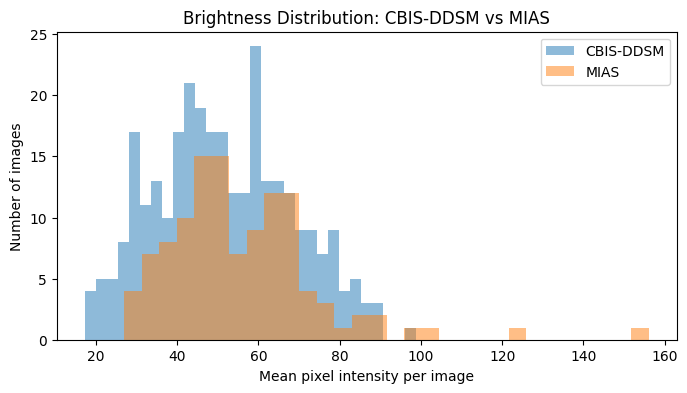

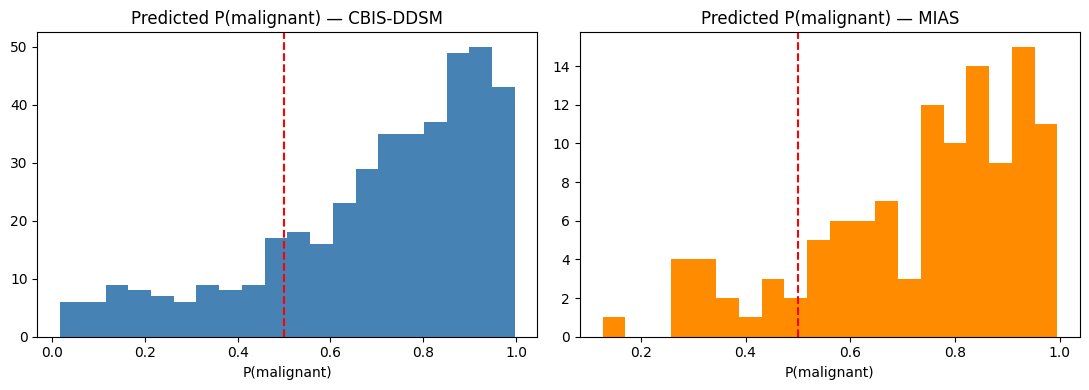

In [ ]:
# ── Per-image brightness & contrast for each dataset ───────────
def dataset_image_stats(paths):
    means, stds = [], []
    for path in paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        means.append(img.mean())
        stds.append(img.std())
    return np.array(means), np.array(stds)

cbis_means, cbis_stds = dataset_image_stats(train_df['abs_path'].values[:300])

mias_means, mias_stds = [], []
for img in mias_images:
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mias_means.append(resized.mean())
    mias_stds.append(resized.std())
mias_means, mias_stds = np.array(mias_means), np.array(mias_stds)

print("── Dataset image statistics ──")
print(f"CBIS-DDSM brightness (mean): {cbis_means.mean():.1f}")
print(f"MIAS      brightness (mean): {mias_means.mean():.1f}")
print(f"CBIS-DDSM contrast   (std) : {cbis_stds.mean():.1f}")
print(f"MIAS      contrast   (std) : {mias_stds.mean():.1f}")

# ── Brightness distribution histogram ──────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(cbis_means, bins=30, alpha=0.5, label='CBIS-DDSM')
plt.hist(mias_means, bins=30, alpha=0.5, label='MIAS')
plt.xlabel("Mean pixel intensity per image")
plt.ylabel("Number of images")
plt.title("Brightness Distribution: CBIS-DDSM vs MIAS")
plt.legend(); plt.show()

# ── Model prediction distributions (shows the bias) ────────────
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(resnet_res['y_prob'], bins=20, color='steelblue')
ax[0].axvline(0.5, color='red', linestyle='--')
ax[0].set_title('Predicted P(malignant) — CBIS-DDSM'); ax[0].set_xlabel('P(malignant)')
ax[1].hist(mias_res['y_prob'], bins=20, color='darkorange')
ax[1].axvline(0.5, color='red', linestyle='--')
ax[1].set_title('Predicted P(malignant) — MIAS'); ax[1].set_xlabel('P(malignant)')
plt.tight_layout(); plt.show()

## Cell 14 — Domain-Shift Mitigation: Histogram Matching (corrected)

Cell 13 will show the datasets have different intensity distributions. Here we
test whether aligning MIAS intensities to CBIS-DDSM (via histogram matching)
recovers performance.

Corrections: the reference is built from the **training** set (not test), and
matched images are supplied in the same 0–1 range as training (the model
applies its own preprocessing internally — we do not call `resnet_pre` here).

Histogram matching applied to 115 MIAS images.


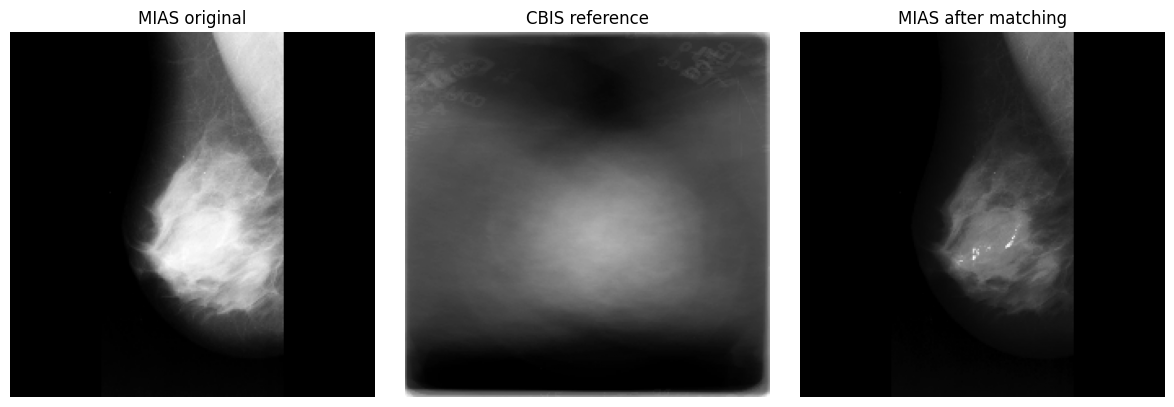

8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step

── ResNet50 on MIAS (histogram matched) ──
Accuracy    : 0.5478
ROC-AUC     : 0.5830
PR-AUC      : 0.5264
Sensitivity : 0.6538  (malignant recall)
Specificity : 0.4603  (benign recall)
              precision    recall  f1-score   support

      Benign       0.62      0.46      0.53        63
   Malignant       0.50      0.65      0.57        52

    accuracy                           0.55       115
   macro avg       0.56      0.56      0.55       115
weighted avg       0.56      0.55      0.55       115

Confusion matrix [[TN FP][FN TP]]:
 [[29 34]
 [18 34]]

FINAL CROSS-DATASET COMPARISON (ResNet50)
Setting                     Acc     AUC     Sens    Spec    
CBIS-DDSM (same)            0.624   0.686   0.920   0.322   
MIAS (no adaptation)        0.400   0.530   0.788   0.079   
MIAS (histogram matched)    0.548   0.583   0.654   0.460   


In [ ]:
from skimage.exposure import match_histograms

# Reference from TRAINING images (not test)
ref_imgs = []
for p in train_df['abs_path'].values[:30]:
    im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    ref_imgs.append(cv2.resize(im, (IMG_SIZE, IMG_SIZE)))
reference = np.mean(ref_imgs, axis=0).astype('uint8')

# Histogram-match each MIAS image, output in 0-1 range
def prep_mias_matched(img):
    grey = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype('uint8')
    matched = match_histograms(grey, reference)
    matched = np.clip(matched, 0, 255).astype('uint8')
    rgb = cv2.cvtColor(matched, cv2.COLOR_GRAY2RGB)
    return rgb.astype('float32') / 255.0     # 0-1, NO resnet_pre

X_mias_matched = np.stack([prep_mias_matched(im) for im in mias_images])
print("Histogram matching applied to", len(X_mias_matched), "MIAS images.")

#  Visual check ───────────────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(cv2.resize(mias_images[0], (IMG_SIZE, IMG_SIZE)), cmap='gray')
ax[0].set_title('MIAS original'); ax[0].axis('off')
ax[1].imshow(reference, cmap='gray')
ax[1].set_title('CBIS reference'); ax[1].axis('off')
matched_vis = match_histograms(
    cv2.resize(mias_images[0], (IMG_SIZE, IMG_SIZE)).astype('uint8'), reference)
ax[2].imshow(matched_vis, cmap='gray')
ax[2].set_title('MIAS after matching'); ax[2].axis('off')
plt.tight_layout(); plt.show()

# ── Re-evaluate on matched MIAS ────────────────────────────────
mias_matched_res = evaluate_model(resnet, "ResNet50 on MIAS (histogram matched)",
                                  is_array=True, X=X_mias_matched, y=mias_labels)

# ── Final three-way comparison ─────────────────────────────────
print("\n" + "="*60)
print("FINAL CROSS-DATASET COMPARISON (ResNet50)")
print("="*60)
print(f"{'Setting':<28}{'Acc':<8}{'AUC':<8}{'Sens':<8}{'Spec':<8}")
print(f"{'CBIS-DDSM (same)':<28}{resnet_res['accuracy']:<8.3f}{resnet_res['auc']:<8.3f}"
      f"{resnet_res['sensitivity']:<8.3f}{resnet_res['specificity']:<8.3f}")
print(f"{'MIAS (no adaptation)':<28}{mias_res['accuracy']:<8.3f}{mias_res['auc']:<8.3f}"
      f"{mias_res['sensitivity']:<8.3f}{mias_res['specificity']:<8.3f}")
print(f"{'MIAS (histogram matched)':<28}{mias_matched_res['accuracy']:<8.3f}{mias_matched_res['auc']:<8.3f}"
      f"{mias_matched_res['sensitivity']:<8.3f}{mias_matched_res['specificity']:<8.3f}")

## Conclusion

This project set out to test whether a deep learning model trained to detect
breast cancer on one mammography dataset could work on another. Using
CBIS-DDSM for training and MIAS for comparison, I built and compared three
models, with ResNet50 performing best (AUC 0.63). Grad-CAM confirmed the
model focused on breast tissue rather than image artefacts.

The key finding came from the cross-dataset test: when the CBIS-DDSM-trained
model was applied to MIAS, its performance collapsed to random (AUC 0.50),
clearly demonstrating domain shift. Attempting to fix this with histogram
matching did not recover performance, showing that the gap between the
datasets runs deeper than simple brightness differences.

Overall, the project shows that strong results on one dataset do not
guarantee real-world generalisation — an important reminder for the safe use
of AI in medical imaging. Future work could explore stronger domain
adaptation methods and training across multiple datasets.